### Computational Holography

Before even connecting a physical spatial light modulator (SLM), 
`slmsuite`'s hardware simulation, modular iterative holography algorithms, GPU acceleration, 
and ... suite ... of toolboxes make it a powerful tool 
for computational holography education, exploration, and research.   

In this first tutorial, we'll walk through the basic functionality. Specifically, we will:

- Understand the connection between the SLM's nearfield and farfield
- Program and visualize various target farfield patterns (spot arrays)
- Solve for the associated nearfield phase masks using iterative Fourier transform (e.g. Gerchberg-Saxton or "GS") algorithms 
- Compare convergence and pattern uniformity with various flavors of GS
- Generalize these principles from spot arrays to images

#### SLM Fundamentals

How can we steer light across free space? A simple example is to tilt a mirror (see **a**, below) which
steers the angle $\theta$ of a beam in the farfield for a $\theta/2$ tilt.
Phase-mode spatial light modulators are specialized displays whose pixels *delay* the wavefront of
light. SLMs can therefore accomplish the same exact action of a tilted mirror -- i.e. a linear delay --
by applying a linear phase shear to the display (see **b**). Hardware limitations (which restrict achievable phase shifts
to order $2\pi$) usually necessitate that this phase is wrapped in the manner of a 
[fresnel lens](https://en.wikipedia.org/wiki/Fresnel_lens) such that a larger tilt (i.e., phase gradient) can
be applied on the display. The nearfield is related to the farfield by the Fourier
transform, an inherent property of free-space propagation, so this linear shear in phase
corresponds to the expected shift in the farfield (see **c**).
We often think of the farfield as the '$k$-space', or the space comprising of beams of
light propagating along vectors $\vec{k}$ at infinity. Here, we often use normalized units
$
\begin{align}
k_x = \frac{\vec{k} \cdot \hat{x}}{|\vec{k}|}
\end{align}
$
which are equivalent to $\theta$ within the small angle approximation which SLMs usually
operate under (the maximum steering range $\theta = \lambda/\Lambda$ is on the order of a few degrees
for common pixel pitches $\Lambda\sim 10 \lambda$). In **b** and **c** of the animation, for example, the
SLM steers to the time-varying target angle $k'_x$ in the far-field. Even though we depict the farfield
pattern as an infinitely narrow $\delta$ function, the true spot width $\delta k'_x = 1/L$ for 
the aperture size $L = N\Lambda$ is governed by the diffraction limit. 

These principles readily extend to steering in two
dimensions as illustrated in  **d** and **e**. 

![Beamsteering in 1D and 2D](fourier_shearing_mod2_small.gif)

Propagating to infinity (and even sometimes to the true farfield requirement $z\sim L^2/\lambda$ for an SLM
aperture dimension $L$) is a lot to ask of an experimental setup, so
we can alternatively use a lens to focus the farfield pattern to an imaging plane.
The simplest setup for a phase-type (e.g. LCOS) SLM places the device one focal length
($f$) in front of a lens to produce a desired image or pattern in the conjugate
focal plane (i.e. the imaging plane a distance $f$ behind the lens). In this common configuration, 
the lens counteracts the parabolic farfield focal plane such that the the SLM
and imaging plane are ideally related by the Fourier transform (unfortunately, various types of
aberration often stymie this). 

More complicated setups (e.g., microscopes) often use systems of lenses; however, 
the power of the imaging system can still
be distilled into some effective focal length $f$. This $f$ can be used to calculate
a number of useful experimental properties of the system:

- For a beam steered along a given $k_x$, the position in the imaging plane is $X =
  k_xf$. Future tutorials will show how `slmsuite` automatically measures $f$ to calibrate
  transformation between nearfield and farfield positions.
- For an SLM with pixel pitch $\Lambda$, the Nyquist-limited edge of the farfield (the
  field of view of the SLM) is $k_\text{max} = \pm\frac{\lambda}{2\Lambda}$ corresponding
  to $X_\text{max} = \pm\frac{\lambda f}{2\Lambda}$. Such a pattern corresponds to the
  phase pattern $\cdots 0, \pi, 0, \pi, 0, \pi, \cdots$ (though by symmetry this pattern deflects power
  to both the positive and negative orders).

`slmsuite` handles much of this math internally. We will next explore the relationship
between the nearfield and farfield using `slmsuite`.

#### Beam Steering in `slmsuite`

In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

import slmsuite

We can use `slmsuite`'s phase retrieval algorithms to solve for the unknown nearfield
phase pattern (that we'll eventually apply to our SLM in an experiment) that reproduces
the desired farfield target in the imaging plane. Let's try it out with a simple
farfield pattern: a single target pixel illuminated on a $32 \times 32$ pixel grid.

[INF] 21:29:53 Hologram Initialized Hologram.


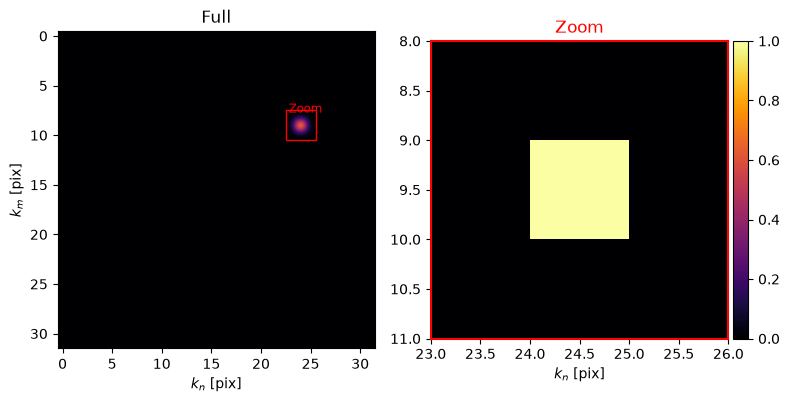

In [2]:
# Import phase retrieval algorithms
from slmsuite.holography.algorithms import Hologram

# Make the desired image: a random pixel targeted in a 32x32 grid
target_size = (32, 32)
target = np.zeros(target_size)
target[9, 24] = 1

# Initialize the hologram and plot the target
# Note: For now, we'll assume the SLM and target are the same size (since they're a Fourier pair)
slm_size = target_size
hologram = Hologram(target, slm_shape=slm_size)
zoombox = hologram.plot_farfield(source=hologram.target, cbar=True)

In this case, we plotted the target in the basis ``"knm"`` representing the pixel indices of the SLM's computational $k$-space (here, ``"knm"`` is aligned with the farfield camera's pixels -- the ``"ij"`` basis -- so the two are synonymous). However, since this plane and the SLM plane are a Fourier pair, each target pixel corresponds to a 2D spatial frequency applied in the SLM plane. The exact unit conversion requires some physical properties of the SLM and camera (i.e., the detector imaging the farfield). To illustrate this point, we'll instantiate simulated objects of the SLM and camera classes.

For our computations, these objects are just useful ways to store the simulated SLM and camera properties. In a real experiment, their methods will also control the hardware. 

We'll also instantiate a setup object (of the ``CameraSLM`` class) to store both the camera and SLM. In an actual experiment, the ``CameraSLM`` methods help find the relative orientation between the two devices (and more..).  

In [3]:
# Create a virtual SLM and camera
from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.hardware.cameras.simulated import SimulatedCamera
from slmsuite.hardware.cameraslms import FourierSLM

# Assume a 532 nm laser
wav_um = 0.532
slm = SimulatedSLM((slm_size[1], slm_size[0]), pitch_um=(10, 10), wav_um=wav_um)
camera = SimulatedCamera(slm)

# The setup (a FourierSLM setup with a camera placed in the Fourier plane of an SLM) holds the camera and SLM.
setup = FourierSLM(camera, slm)
hologram.cameraslm = setup

[INF] 21:29:53 SimulatedSLM Initialized SimulatedSLM.
[WRN] 21:29:53 SimulatedSLM Resolution of (32, 32) is unusual. Was this a typo?
[INF] 21:29:53 SimulatedCamera Initialized SimulatedCamera.
[WRN] 21:29:53 SimulatedCamera Resolution of (32, 32) is unusual. Was this a typo?
[INF] 21:29:53 Hologram #2 Initialized Hologram.
[INF] 21:29:53 SimulatedCamera-SimulatedSLM Initialized FourierSLM.


With these objects created, we can now re-plot the target image plane in various spatial frequency units. See the ``slmsuite.holography.toolbox.convert_vector`` function documentation for definitions of these units. 

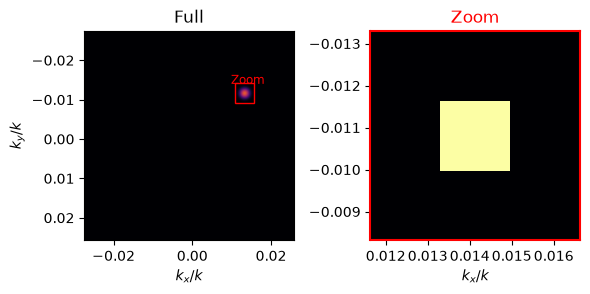

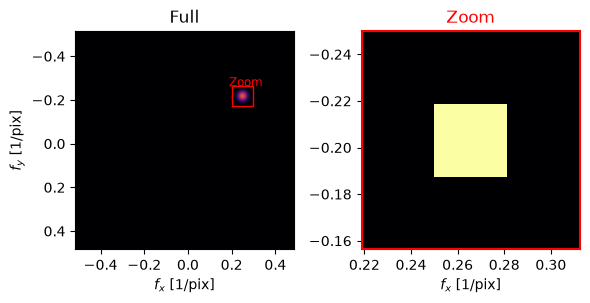

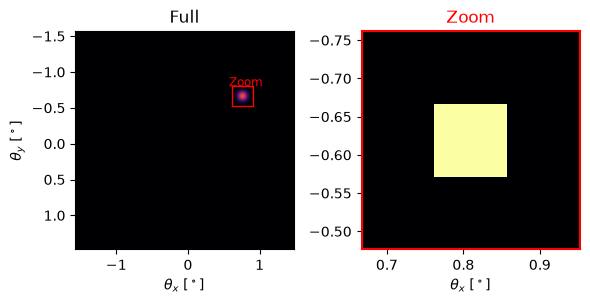

In [4]:
# Not all inclusive, but try out a few units
for units in ["kxy", "freq", "deg"]:
    hologram.plot_farfield(source=hologram.target, units=units, figsize=(6,3))

With a solid understanding of the near- and farfield characteristics, we can now move onto actually solving for the nearfield phase mask. We'll start with the classic [Gerchberg-Saxton iterative Fourier transform algorithm](https://en.wikipedia.org/wiki/Gerchberg%E2%80%93Saxton_algorithm).

100%|██████████| 5/5 [00:00<00:00, 350.64it/s]


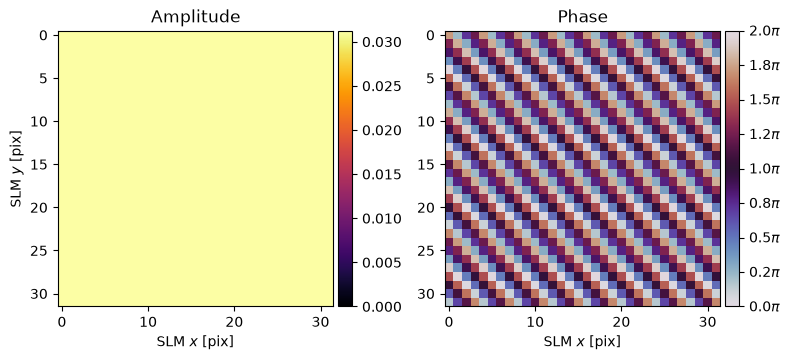

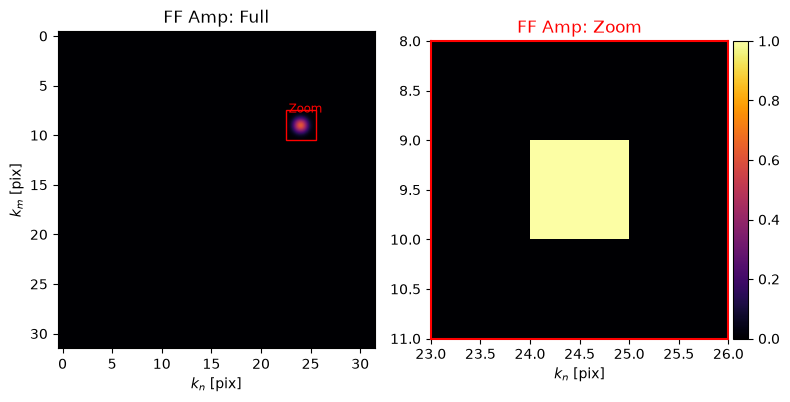

In [5]:
# Run 5 iterations of GS.
hologram.optimize(method='GS', maxiter=5)

# Look at the associated near- and far- fields
hologram.plot_nearfield(cbar=True)
hologram.plot_farfield(limits=zoombox, cbar=True, title='FF Amp');

The nearfield amplitude is unity (the SLM class assumes uniform illumination by default) and GS calculated a beautiful diagonal grating with a ~4 pixel horizontal/vertical period as expected from the unit conversion plots above (see the `"freq"` unit conversion plot, where $1/f_x\sim 1/f_y\approx 1/4$).

While at first glance it looks like the GS-computed phase mask *exactly* reproduces the
desired farfield target pattern, this is actually not the case. From basic Fourier
theory, we know that a uniformly illuminated aperture (comprising $N$ pixels at pitch
$\Lambda$) will emit a beamwidth $\delta k_x \approx \lambda/N\Lambda$. Sampling in increments
of $\Lambda$ in the nearfield also corresponds to a total spatial frequency range of
$\lambda/\Lambda$, which yields a bin width $\lambda/N\Lambda$ for $N$ pixels. So it only appears that
we created the perfect target pattern because each pixel in the farfield corresponds to
a diffraction-limited spot. 

To see the true pattern, we can increase the farfield resolution by zero-padding the nearfield.

[INF] 21:29:54 Hologram #3 Initialized Hologram.


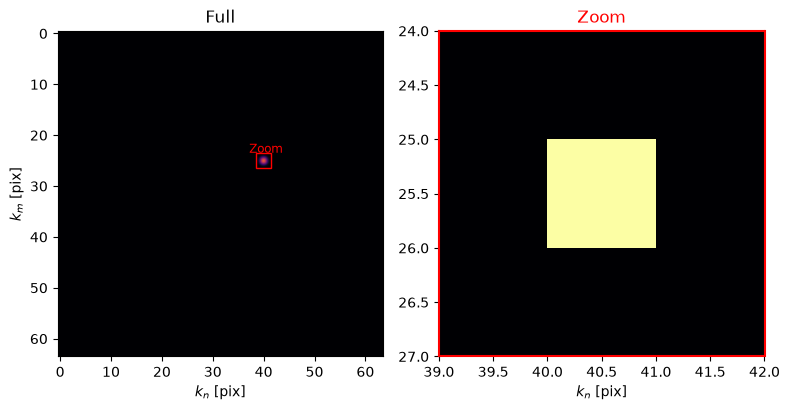

100%|██████████| 5/5 [00:00<00:00, 4763.01it/s]


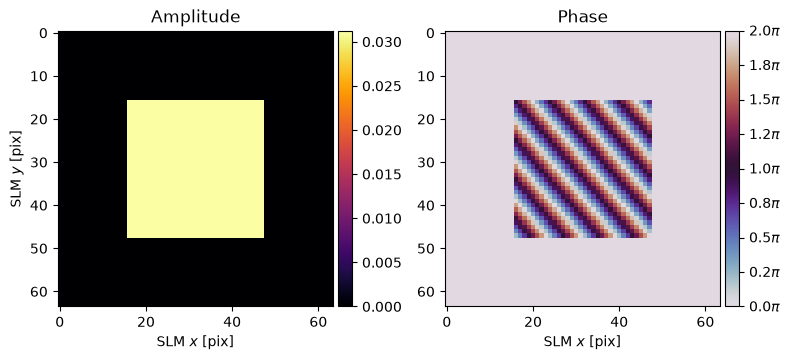

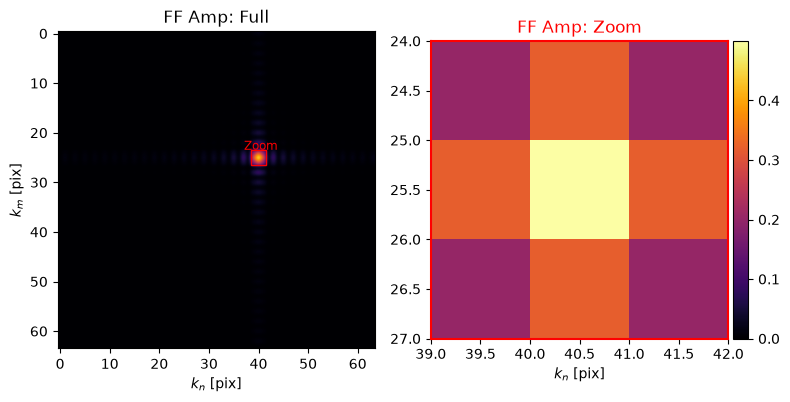

In [6]:
from slmsuite.holography import toolbox

# Get the padding needed to resolve 2x smaller than a diffraction limited spot
# (N.b. slm.pitch, like all length variables in slmsuite, is wavelength-normalized)
slm_length = slm.pitch[0]*slm.shape[0]
padded_shape = Hologram.get_padded_shape(setup, precision=0.5/slm_length)
target_padded = toolbox.pad(target, padded_shape)

# Recompute the farfield
hologram = Hologram(target_padded, slm_shape=slm.shape)
zoombox_padded = hologram.plot_farfield(target_padded)
hologram.optimize(method='GS', maxiter=5)

# Look at the associated near- and far- fields
hologram.plot_nearfield(padded=True, cbar=True)
hologram.plot_farfield(cbar=True, units="deg", title='FF Amp', limits=zoombox_padded);

Likewise, farfield pixels are also smaller than diffraction limited spots when the nearfield amplitude doesn't fully fill the SLM aperture as illustrated below.

[INF] 21:29:54 Hologram #4 Initialized Hologram.


100%|██████████| 5/5 [00:00<00:00, 1072.55it/s]


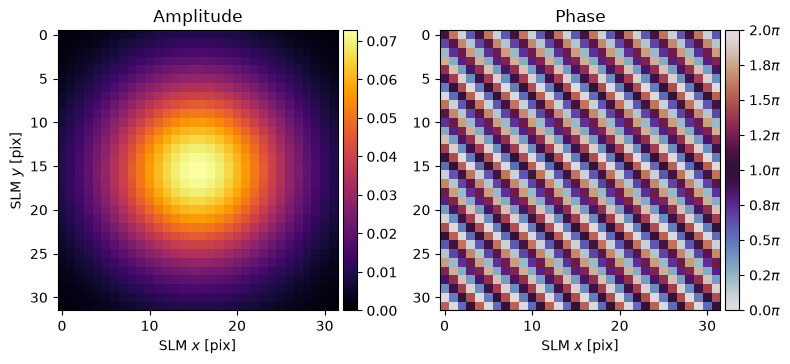

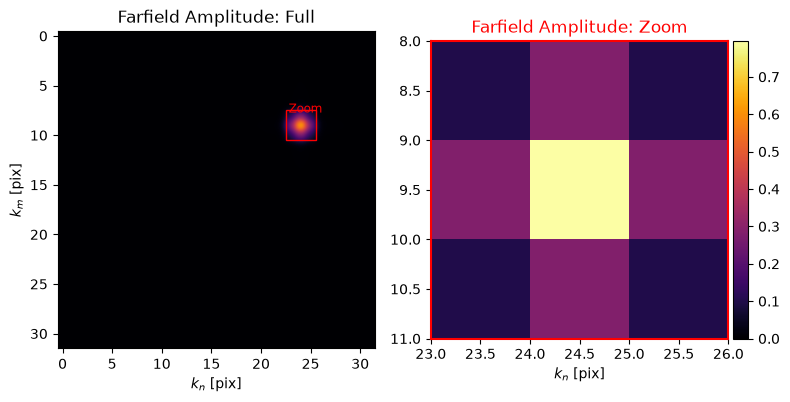

In [7]:
# Set a Gaussian amplitude profile on SLM
slm.set_source_analytic()   # With no arguments, defaults to a beamradius equal to half the aperture size

# Redo the same GS calculations
hologram = Hologram(target, slm_shape=slm.shape, amp=slm.source["amplitude"])
hologram.optimize(method='GS', maxiter=5)

hologram.plot_nearfield(padded=True, cbar=True)
hologram.plot_farfield(cbar=True, limits=zoombox);

#### Spot Arrays

Now that we've discussed bare-bones GS algorithms, SLM setups, and Fourier principles, we can move onto more realistic targets. Here, for example, we'll start looking at many spots in the target plane instead of a single one. These patterns may seem simple but are actually an enabling tool for state-of-the-art [quantum computing](https://www.nature.com/articles/s41586-021-03582-4) (where arrays of optical tweezers -- the topic of the [2018 Nobel Prize in Physics](https://www.aps.org/publications/apsnews/201811/nobel18.cfm) -- trap and excite atom arrays), [optogenetics](https://www.nature.com/articles/s41593-021-00902-9) (where desired neurons are dynamically excited), and [laser printing](https://www.nature.com/articles/s41377-019-0215-1).

Let's give it a shot with ``SpotHologram``, a child of the ``Hologram`` "super-class" with various utilities for making and characterizing spot arrays.

[INF] 21:29:54 SpotHologram Initialized SpotHologram.


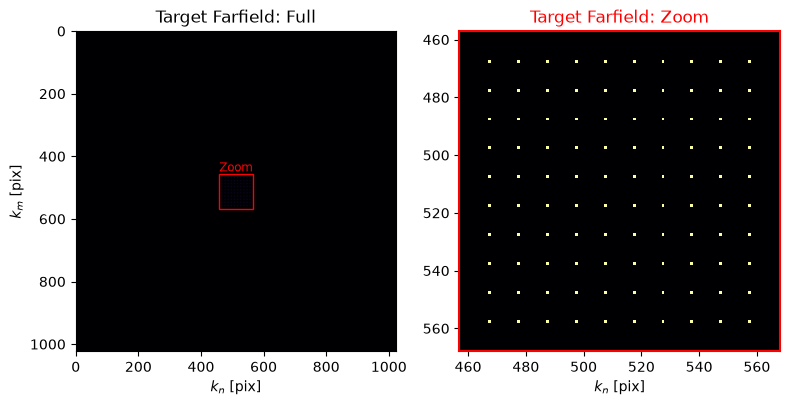

In [8]:
from slmsuite.holography.algorithms import SpotHologram

# Move to a larger grid size
slm_size = (1024, 1024)

# Instead of picking a few points, make a rectangular grid in the knm basis
array_holo = SpotHologram.make_rectangular_array(
    slm_size,
    array_shape=(10,10),
    array_pitch=(10,10),
    basis='knm'
)
zoom = array_holo.plot_farfield(source=array_holo.target, title='Target Farfield')

Now we'll run the optimization to produce our intended target: a farfield array of optical foci with uniform amplitude. For ease, the ``optimize`` method uses a parameter naming convention borrowed from [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html). It's therefore simple enough to add a callback function that runs during each iteration of GS, which we demonstrate below.

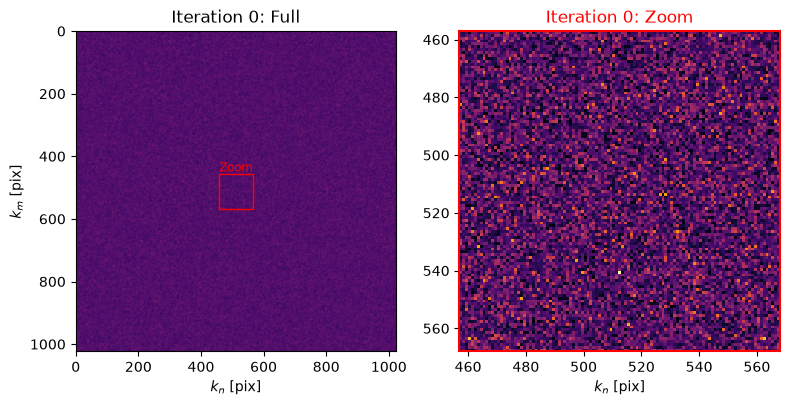

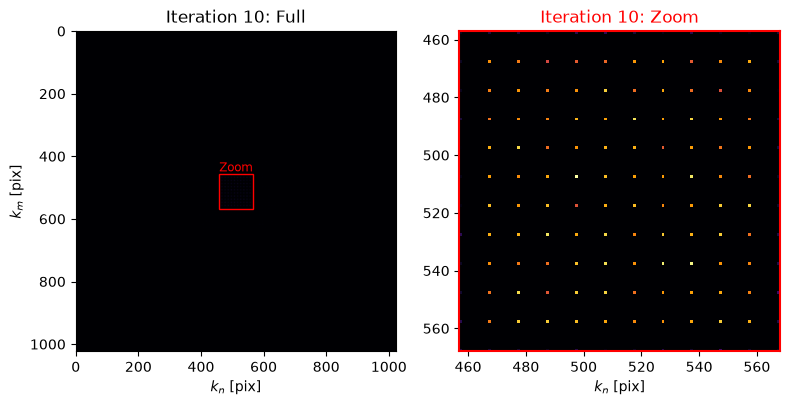

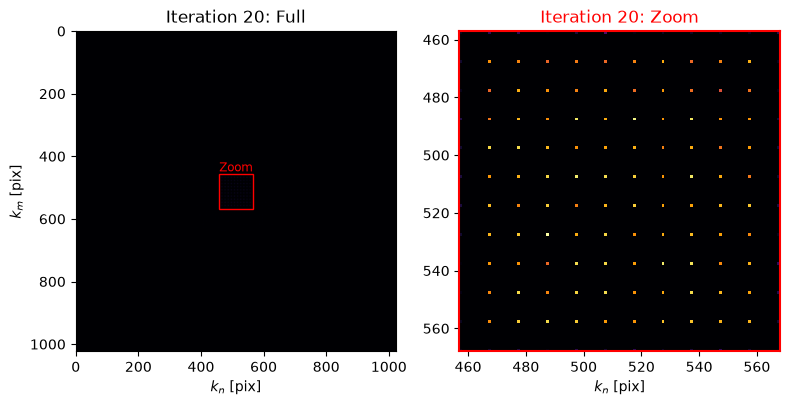

In [9]:
# Example callback function: plot the FF every 10 iterations
def plot_ff(holo):
    if holo.iter % 10 == 0:
        holo.plot_farfield(limits=zoom, title='Iteration %d'%holo.iter)

# Now we'll run the computation using 21 iterations of GS.
array_holo.optimize(method="GS", maxiter=21, callback=plot_ff,
                    stat_groups=['computational_spot'], verbose=False)

We see here that GS converges within a few steps to an image close to our target pattern. But how close? In the cell above, the addition of the ``stat_groups=['computational']`` parameter to the optimization loop had dual purpose: it 1) calculated statistics of the spot array uniformity and efficiency at each step of the GS optimization which 2) forced ``array_holo.amp_ff`` to be computed so that we could plot it with our callback function (for speed, ``amp_ff`` is not calculated at each optimization step unless needed). 

*Sidenote: statistics computation slows down GS (due to data transfer between* ``numpy`` *and* ``cupy`` *objects during each GS iteration) but has been heavily optimized to limit the performance loss.*

We can now plot the algorithm convergence (to see "how close" we got to the target) and the final nearfield phase mask produced by the algorithm.

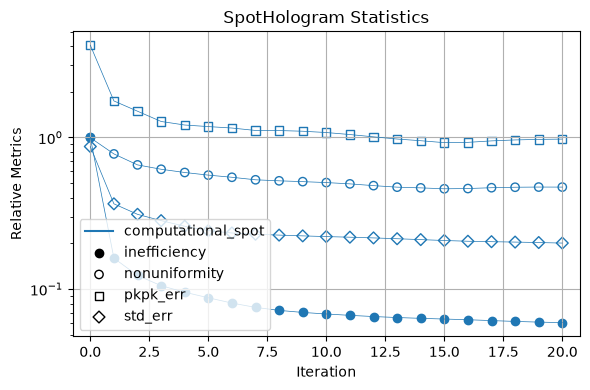

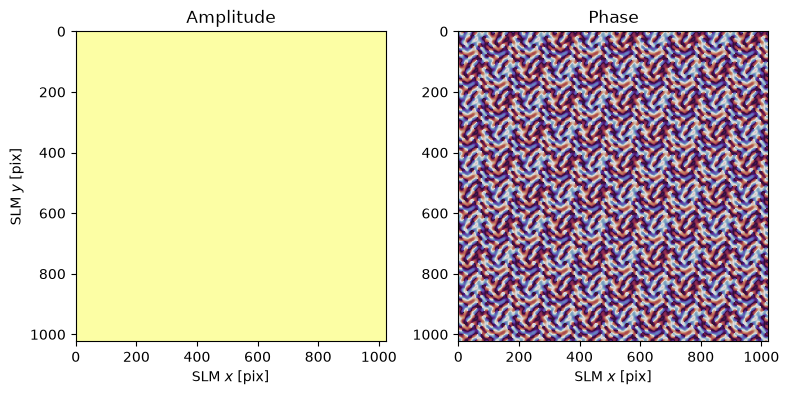

In [10]:
array_holo.plot_stats()
array_holo.plot_nearfield()

#### Comparing Algorithms

For the default GS algorithm, the inefficiency (fraction of power off-target), non-uniformity, and associated amplitude errors converge within a handful of optimization iterations. The resulting uniformity isn't stellar. Fortunately, a number of other "weighted" (i.e. "WGS") GS algorithms can improve these results. 

A complete listing of implemented algorithms can be found in the [`slmsuite` documentation](https://slmsuite.readthedocs.io/en/latest/index.html). Here, we'll use a recently-developed [fixed-phase WGS algorithm](https://opg.optica.org/ol/abstract.cfm?uri=ol-44-12-3178) to compare to basic GS.

[DBG] 21:29:55 SpotHologram Optimizing with 'WGS-Kim' using method-specific flags: {'feedback': 'computational', 'fix_phase_efficiency': None, 'fix_phase_iteration': 10, 'feedback_exponent': 0.8}


  0%|          | 0/21 [00:00<?, ?it/s]

[DBG] 21:29:55 SpotHologram Optimizing with 'WGS-Kim' for 21 iteration(s).


100%|██████████| 21/21 [00:00<00:00, 376.22it/s]


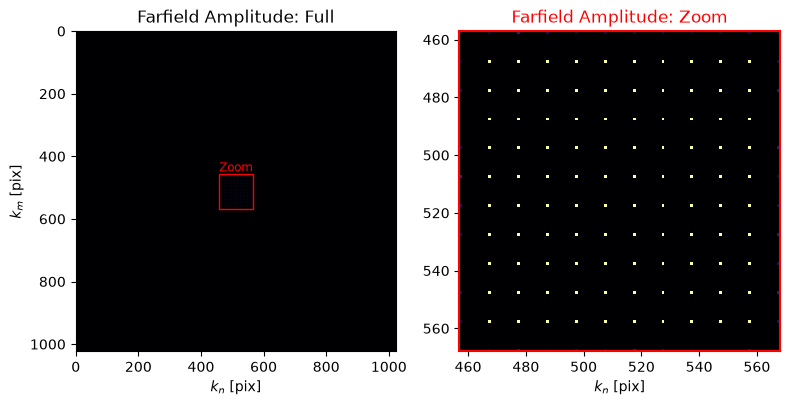

In [11]:
# Retry with WGS using a fixed-phase algorithm
import copy
import logging

wgs_holo = copy.deepcopy(array_holo)
wgs_holo.reset()

# Configure logging to debug so we can see optimization options
slmsuite.configure_logging(logging.DEBUG)
wgs_holo.optimize(method="WGS-Kim", maxiter=21, stat_groups=['computational_spot'])
wgs_holo.plot_farfield(limits=zoom);

# Switch logging back to INFO (default level)
slmsuite.configure_logging(logging.INFO)

With the logger at `DEBUG`, `optimize` reports the flags being used by the optimization algorithm. Default values are assigned in `slmsuite` but you can pass any of these flags as an `optimize` argument to change the algorithm behavior (the `stat_groups` list is one example shown here).

#### A Brief Sidebar on Logging

`slmsuite` uses the standard Python [`logging`](https://docs.python.org/3/library/logging.html) module. As a result:

- **Console verbosity** is set by `slmsuite.configure_logging(level)`. `logging.DEBUG` adds internals like the algorithm flags above, `logging.WARNING` quiets routine chatter, and `None` removes the console handler entirely.
- **Records are always captured**, whatever the console level. `slmsuite.get_log()` returns every record from the session, and each object carries its own log: `wgs_holo.get_log()`, `slm.get_log()`, `cam.get_log()`, and so on. These per-object logs travel with the object when it is saved or pickled, which makes a saved hologram or calibration self-documenting.
- **`obj.log_state()`** writes the object's tracked attributes to the log, which is a good first step when something misbehaves.
- Because this is stdlib `logging`, the `"slmsuite"` logger can be routed into your own handlers (a file, a GUI, your lab's logging infrastructure) alongside or instead of the console.

With that in mind, let's now compare the results.

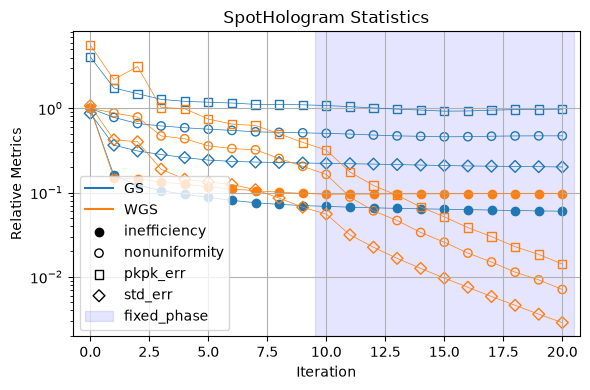

In [12]:
# Combine the statistics and compare
statscombined = wgs_holo.stats
statscombined["stats"]['WGS'] = statscombined["stats"].pop("computational_spot")
statscombined["stats"]["GS"] = array_holo.stats["stats"]["computational_spot"]

# (Optional) Reverse order to plot GS first
statscombined["stats"] = dict(reversed(list(statscombined["stats"].items())))

ax = wgs_holo.plot_stats(statscombined)

Much better: the WGS algorithm quickly converges once the farfield phase is fixed (defined here by the ``WGS-Kim`` algorithm's default ``fix_phase_iteration=10`` setting) at the cost of a slight efficiency reduction. 

#### Basic Image Formation

The same algorithms can be applied to more complex patterns, like pictures. Notice that the image is very good, but not perfect. This is because perfect nearfield phase retrieval is impossible in general for a fixed nearfield amplitude distribution (in our case, the amplitude is uniform by default).

[INF] 21:29:56 Hologram #5 Initialized Hologram.


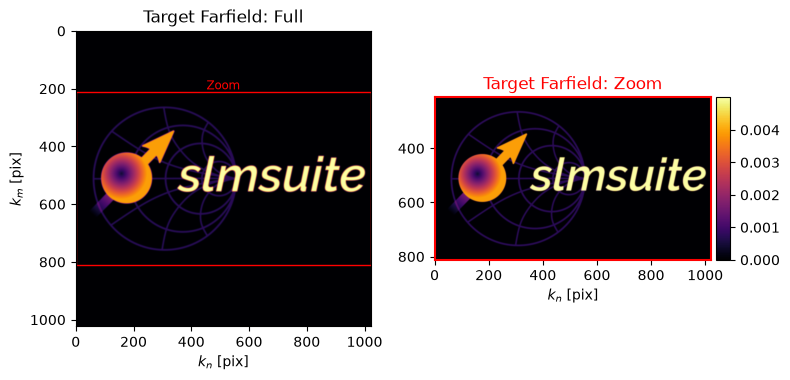

100%|██████████| 21/21 [00:00<00:00, 849.39it/s]


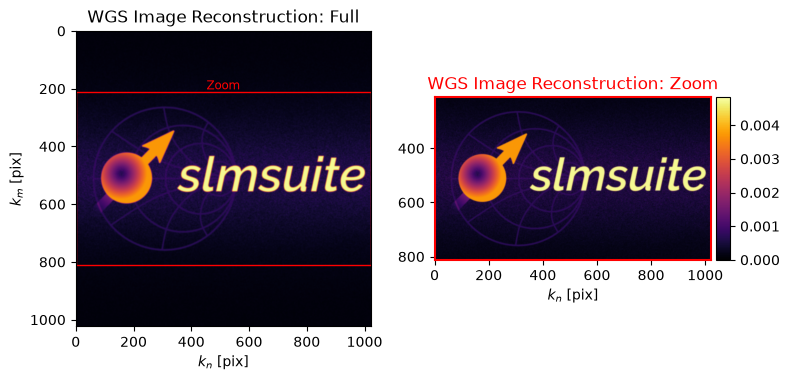

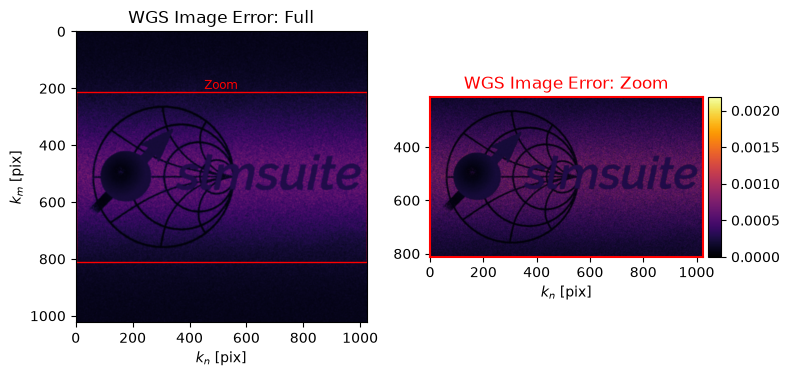

In [13]:
import cv2

# Use a random logo
path = os.path.join(os.getcwd(), '../../slmsuite/docs/source/static/slmsuite-small.png')
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
assert img is not None, "Could not find this test image!"
img = cv2.bitwise_not(img) # Invert

# Resize (zero pad) for GS.
shape = (1024,1024)
target = toolbox.pad(img, shape)

holo = Hologram(target)
zoom = holo.plot_farfield(holo.target, cbar=True, title='Target Farfield')

holo.optimize(method="WGS-Kim", maxiter=21)
holo.plot_farfield(limits=zoom, title='WGS Image Reconstruction', cbar=True)
holo.plot_farfield(np.abs(holo.target - holo.amp_ff), limits=zoom, title='WGS Image Error', cbar=True);

We'll return to image formation in the experimental holography tutorial.

#### Future Development

Notice that each example in this notebook took about a second or less to run: ``slmsuite`` is fast. In the future, we'll continue to add more algorithms to assist in the development of new SLM tools and techniques. Stay tuned for updates!